# E-commerce 90-Day Purchase Inactivity Prediction

## Business question

If the business can contact only a limited number of customers each month, who should receive priority? At the beginning of each month, this project creates a customer snapshot from the previous 180 days of transactions and predicts whether the customer will make **no successful purchase during the following 90 days**.

The target is described as 90-day purchase inactivity rather than permanent churn. The public transactions contain no account closure, subscription termination, or explicit customer-departure field; a 90-day absence is a reproducible operational proxy.

## Project highlights

- Uses more than one million real transaction lines rather than a simulated churn label;
- Converts transaction details into a deployable customer-month feature table;
- Uses rolling time validation with a 90-day purge gap so training labels mature before each validation point;
- Compares Logistic Regression, Random Forest, HistGradientBoosting, and XGBoost;
- Reports PR-AUC, ROC-AUC, Brier score, Top-10% recall, and lift rather than accuracy alone;
- Translates model scores into a capacity-constrained priority list without making causal claims.


## 1. Data source and interpretation boundary

The data come from **Online Retail II** in the UCI Machine Learning Repository: transactions from a UK-based non-store retailer between 1 December 2009 and 9 December 2011. Fields include invoice, product, quantity, timestamp, unit price, customer, and country, with cancellations and missing customer identifiers.

- Official page: https://archive.ics.uci.edu/dataset/502/online+retail+ii
- DOI: https://doi.org/10.24432/C5CG6D
- License: CC BY 4.0

**Interpretation boundary:** the model predicts the probability of no successful purchase during the next 90 days, not permanent customer departure. Predictive association is also not the causal increment from a retention action. Coupons and outreach still require a randomized experiment.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

# Locate the raw data automatically from the portfolio root, project directory, or notebooks directory.
search_roots = [Path.cwd(), *Path.cwd().parents]
PORTFOLIO_ROOT = next(
    root for root in search_roots
    if (root / "data/raw/online_retail_ii/online_retail_II.xlsx").exists()
)
DATA_PATH = PORTFOLIO_ROOT / "data/raw/online_retail_ii/online_retail_II.xlsx"
PROJECT_DIR = PORTFOLIO_ROOT / "projects/15_ecommerce_churn_prediction"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data file: {DATA_PATH.relative_to(PORTFOLIO_ROOT)}")
print(f"Output directory: {OUTPUT_DIR.relative_to(PORTFOLIO_ROOT)}")
display(Markdown("**Result interpretation:** Path validation passed. Subsequent outputs are stored in this project's `outputs` directory without creating additional scattered folders."))


Data file: data\raw\online_retail_ii\online_retail_II.xlsx
Output directory: projects\15_ecommerce_churn_prediction\outputs


**Result interpretation:** Path validation passed. Subsequent outputs are stored in this project's `outputs` directory without creating additional scattered folders.

## 2. Read both transaction years and audit the raw data

In [2]:
sheet_names = pd.ExcelFile(DATA_PATH).sheet_names
raw_parts = [pd.read_excel(DATA_PATH, sheet_name=sheet) for sheet in sheet_names]
raw = pd.concat(raw_parts, ignore_index=True)
raw.columns = [
    "invoice", "stock_code", "description", "quantity",
    "invoice_date", "unit_price", "customer_id", "country"
]
raw["invoice_date"] = pd.to_datetime(raw["invoice_date"])

audit = pd.DataFrame({
    "Metric": ["Worksheets", "Transaction lines", "Start timestamp", "End timestamp", "Unique invoices", "Unique customers (non-missing)", "Missing customer-ID rate"],
    "Result": [
        ", ".join(sheet_names), f"{len(raw):,}", str(raw.invoice_date.min()),
        str(raw.invoice_date.max()), f"{raw.invoice.nunique():,}",
        f"{raw.customer_id.nunique(dropna=True):,}", f"{raw.customer_id.isna().mean():.2%}"
    ]
})
display(audit)
display(raw.head())

display(Markdown(
    f"**Result interpretation:** The raw file contains **{len(raw):,}** product lines and "
    f"**{raw.customer_id.nunique(dropna=True):,}** identifiable customers, covering "
    f"**{raw.invoice_date.min():%Y-%m-%d} to {raw.invoice_date.max():%Y-%m-%d}**。"
    f"The missing customer-ID rate is **{raw.customer_id.isna().mean():.2%}**. Missing identifiers cannot form customer histories, so those rows remain in the data-quality audit but cannot enter customer-level modeling."
))


,Metric,Result
0,Worksheets,"Year 2009-2010, Year 2010-2011"
1,Transaction lines,"1,067,371"
2,Start timestamp,2009-12-01 07:45:00
3,End timestamp,2011-12-09 12:50:00
4,Unique invoices,"53,628"
5,Unique customers (non-missing),"5,942"
6,Missing customer-ID rate,22.77%


,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom


**Result interpretation:** The raw file contains **1,067,371** product lines and **5,942** identifiable customers, covering **2009-12-01 to 2011-12-09**。The missing customer-ID rate is **22.77%**. Missing identifiers cannot form customer histories, so those rows remain in the data-quality audit but cannot enter customer-level modeling.

## 3. Clean the transactions and separate successful purchases from cancellations / returns

In [3]:
tx = raw.copy()
tx["invoice"] = tx["invoice"].astype(str).str.strip()
tx["stock_code"] = tx["stock_code"].astype(str).str.strip()
tx["is_cancelled"] = tx["invoice"].str.upper().str.startswith("C") | (tx["quantity"] < 0)
tx["line_value"] = tx["quantity"] * tx["unit_price"]

quality = pd.DataFrame({
    "Check": ["Raw lines", "Missing customer ID", "Cancellation / negative-quantity lines", "Non-positive-price lines", "Successful-purchase lines eligible for modeling"],
    "Rows": [
        len(tx), tx.customer_id.isna().sum(), tx.is_cancelled.sum(),
        (tx.unit_price <= 0).sum(),
        ((tx.customer_id.notna()) & (~tx.is_cancelled) & (tx.quantity > 0) & (tx.unit_price > 0)).sum()
    ]
})
quality["Share of raw data"] = quality["Rows"] / len(tx)
display(quality.style.format({"Rows": "{:,.0f}", "Share of raw data": "{:.2%}"}))

successful = tx.loc[
    tx.customer_id.notna() & ~tx.is_cancelled & (tx.quantity > 0) & (tx.unit_price > 0)
].copy()
successful["customer_id"] = successful["customer_id"].astype(int).astype(str)
successful["revenue"] = successful["quantity"] * successful["unit_price"]

returns = tx.loc[tx.customer_id.notna() & tx.is_cancelled].copy()
returns["customer_id"] = returns["customer_id"].astype(int).astype(str)
returns["return_value_abs"] = (returns["quantity"] * returns["unit_price"]).abs()

display(Markdown(
    f"**Result interpretation:** Only the **{len(successful):,}** records with positive quantity and price and no cancellation invoice are treated as successful purchases. "
    "Cancellation and negative-quantity records are not simply discarded; they are retained separately to create cancellation-count and cancelled-value features. "
    "This prevents returns from being counted as new purchases while preserving after-sales signals that may help predict future inactivity."
))


,Check,Rows,Share of raw data
0,Raw lines,"1,067,371",100.00%
1,Missing customer ID,"243,007",22.77%
2,Cancellation / negative-quantity lines,"22,951",2.15%
3,Non-positive-price lines,"6,207",0.58%
4,Successful-purchase lines eligible for modeling,"805,549",75.47%


**Result interpretation:** Only the **805,549** records with positive quantity and price and no cancellation invoice are treated as successful purchases. Cancellation and negative-quantity records are not simply discarded; they are retained separately to create cancellation-count and cancelled-value features. This prevents returns from being counted as new purchases while preserving after-sales signals that may help predict future inactivity.

## 4. Construct customer-month snapshots and the target

For every snapshot date:

- **Observation window:** previous 180 days;
- **Prediction window:** following 90 days;
- **Eligibility:** at least one successful purchase in the observation window;
- **Target `inactive_90d=1`:** no successful purchase in the prediction window;
- **Customer ID is never used as a model feature.**

The same customer may be scored in multiple months, matching a monthly operating process. Validation is separated by time instead of randomly splitting observations from the same period.


,snapshot_date,customers,inactive_customers,inactivity_rate
0,2010-06-01 00:00:00,"2,669","1,337",50.1%
1,2010-07-01 00:00:00,"2,757","1,358",49.3%
2,2010-08-01 00:00:00,"2,822","1,215",43.1%
3,2010-09-01 00:00:00,"2,831","1,078",38.1%
4,2010-10-01 00:00:00,"2,910","1,228",42.2%
5,2010-11-01 00:00:00,"3,209","1,629",50.8%
6,2010-12-01 00:00:00,"3,479","2,159",62.1%
7,2011-01-01 00:00:00,"3,415","2,129",62.3%
8,2011-02-01 00:00:00,"3,359","2,028",60.4%
9,2011-03-01 00:00:00,"3,349","1,933",57.7%


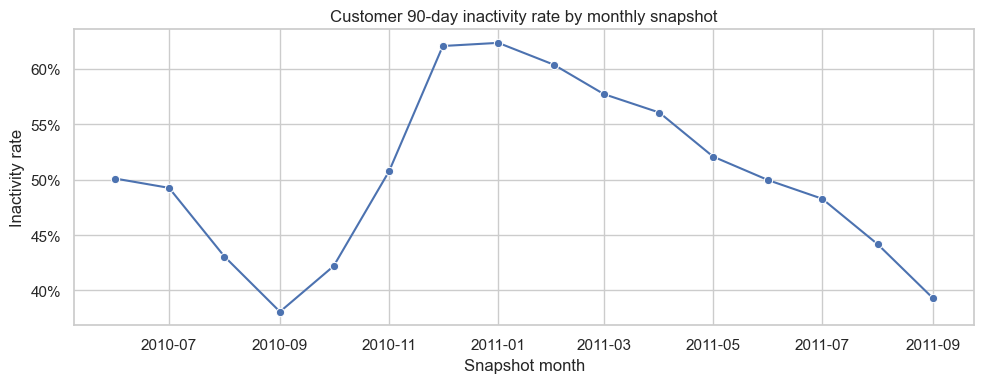

**Result interpretation:** The pipeline creates **48,079** customer-month samples across **16** snapshots. The overall 90-day inactivity rate is **50.9%**。Inactivity changes across months, so random splitting would mix different temporal distributions; model validation must therefore follow time. Snapshots include only customers with a purchase during the previous 180 days. The model answers who among recent customers will stop purchasing, rather than identifying accounts that have already been dormant for years.

In [4]:
FEATURE_COLUMNS = [
    "recency_days", "customer_age_days",
    "orders_30d", "orders_90d", "orders_180d",
    "spend_30d", "spend_90d", "spend_180d",
    "units_30d", "units_90d", "units_180d",
    "avg_order_value_180d", "avg_lines_per_order_180d", "avg_units_per_order_180d",
    "distinct_skus_180d", "active_months_180d",
    "mean_purchase_interval_days", "std_purchase_interval_days",
    "spend_trend_30_vs_prior", "orders_trend_30_vs_prior",
    "cancelled_invoices_180d", "cancelled_value_180d", "is_uk"
]

first_purchase = successful.groupby("customer_id")["invoice_date"].min()

def window_aggregates(lines, snapshot, days, suffix):
    start = snapshot - pd.Timedelta(days=days)
    w = lines.loc[(lines.invoice_date >= start) & (lines.invoice_date < snapshot)].copy()
    if w.empty:
        return pd.DataFrame()
    invoice_level = w.groupby(["customer_id", "invoice"], as_index=False).agg(
        order_date=("invoice_date", "min"),
        order_value=("revenue", "sum"),
        order_units=("quantity", "sum"),
        order_lines=("stock_code", "size")
    )
    customer = invoice_level.groupby("customer_id").agg(
        **{
            f"orders_{suffix}": ("invoice", "nunique"),
            f"spend_{suffix}": ("order_value", "sum"),
            f"units_{suffix}": ("order_units", "sum")
        }
    )
    return customer

def build_snapshot(snapshot):
    lookback_start = snapshot - pd.Timedelta(days=180)
    hist = successful.loc[
        (successful.invoice_date >= lookback_start) & (successful.invoice_date < snapshot)
    ].copy()
    eligible = pd.Index(hist.customer_id.unique(), name="customer_id")
    if len(eligible) == 0:
        return pd.DataFrame()

    base = pd.DataFrame(index=eligible)
    last_purchase = hist.groupby("customer_id")["invoice_date"].max()
    base["recency_days"] = (snapshot - last_purchase).dt.total_seconds().div(86400)
    base["customer_age_days"] = (snapshot - first_purchase.reindex(eligible)).dt.total_seconds().div(86400)

    for days, suffix in [(30, "30d"), (90, "90d"), (180, "180d")]:
        base = base.join(window_aggregates(successful, snapshot, days, suffix), how="left")

    order_level = hist.groupby(["customer_id", "invoice"], as_index=False).agg(
        order_date=("invoice_date", "min"), order_value=("revenue", "sum"),
        order_units=("quantity", "sum"), order_lines=("stock_code", "size")
    )
    detail = order_level.groupby("customer_id").agg(
        avg_order_value_180d=("order_value", "mean"),
        avg_lines_per_order_180d=("order_lines", "mean"),
        avg_units_per_order_180d=("order_units", "mean")
    )
    base = base.join(detail, how="left")
    base["distinct_skus_180d"] = hist.groupby("customer_id")["stock_code"].nunique()
    base["active_months_180d"] = hist.assign(month=hist.invoice_date.dt.to_period("M")).groupby("customer_id")["month"].nunique()

    def interval_stats(group):
        dates = pd.Series(group.order_date.drop_duplicates().sort_values())
        gaps = dates.diff().dt.total_seconds().div(86400).dropna()
        return pd.Series({
            "mean_purchase_interval_days": gaps.mean(),
            "std_purchase_interval_days": gaps.std()
        })
    intervals = order_level.groupby("customer_id", group_keys=False).apply(interval_stats)
    base = base.join(intervals, how="left")

    prior_start = snapshot - pd.Timedelta(days=90)
    recent_start = snapshot - pd.Timedelta(days=30)
    recent = successful.loc[(successful.invoice_date >= recent_start) & (successful.invoice_date < snapshot)]
    prior = successful.loc[(successful.invoice_date >= prior_start) & (successful.invoice_date < recent_start)]
    recent_spend = recent.groupby("customer_id")["revenue"].sum().reindex(eligible, fill_value=0)
    prior_spend_monthly = prior.groupby("customer_id")["revenue"].sum().reindex(eligible, fill_value=0) / 2
    recent_orders = recent.groupby("customer_id")["invoice"].nunique().reindex(eligible, fill_value=0)
    prior_orders_monthly = prior.groupby("customer_id")["invoice"].nunique().reindex(eligible, fill_value=0) / 2
    base["spend_trend_30_vs_prior"] = (recent_spend + 1) / (prior_spend_monthly + 1)
    base["orders_trend_30_vs_prior"] = (recent_orders + 0.5) / (prior_orders_monthly + 0.5)

    r = returns.loc[(returns.invoice_date >= lookback_start) & (returns.invoice_date < snapshot)]
    base["cancelled_invoices_180d"] = r.groupby("customer_id")["invoice"].nunique().reindex(eligible, fill_value=0)
    base["cancelled_value_180d"] = r.groupby("customer_id")["return_value_abs"].sum().reindex(eligible, fill_value=0)
    main_country = hist.groupby("customer_id")["country"].agg(lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown")
    base["is_uk"] = main_country.eq("United Kingdom").astype(int)

    future_end = snapshot + pd.Timedelta(days=90)
    future_buyers = set(successful.loc[
        (successful.invoice_date >= snapshot) & (successful.invoice_date < future_end), "customer_id"
    ])
    base["inactive_90d"] = (~base.index.isin(future_buyers)).astype(int)
    base["snapshot_date"] = snapshot
    return base.reset_index()

snapshot_dates = pd.date_range("2010-06-01", "2011-09-01", freq="MS")
model_data = pd.concat([build_snapshot(date) for date in snapshot_dates], ignore_index=True)
model_data[FEATURE_COLUMNS] = model_data[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)

snapshot_summary = model_data.groupby("snapshot_date").agg(
    customers=("customer_id", "size"),
    inactive_customers=("inactive_90d", "sum"),
    inactivity_rate=("inactive_90d", "mean")
).reset_index()
display(snapshot_summary.style.format({"customers": "{:,.0f}", "inactive_customers": "{:,.0f}", "inactivity_rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=snapshot_summary, x="snapshot_date", y="inactivity_rate", marker="o", ax=ax)
ax.set(title="Customer 90-day inactivity rate by monthly snapshot", xlabel="Snapshot month", ylabel="Inactivity rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Result interpretation:** The pipeline creates **{len(model_data):,}** customer-month samples across **{len(snapshot_dates)}** snapshots. "
    f"The overall 90-day inactivity rate is **{model_data.inactive_90d.mean():.1%}**。"
    "Inactivity changes across months, so random splitting would mix different temporal distributions; model validation must therefore follow time. "
    "Snapshots include only customers with a purchase during the previous 180 days. The model answers who among recent customers will stop purchasing, rather than identifying accounts that have already been dormant for years."
))


## 5. Feature quality and business meaning

In [5]:
feature_dictionary = pd.DataFrame([
    ("recency_days", "Days since the most recent purchase"),
    ("customer_age_days", "Days since the first observed purchase"),
    ("orders/spend/units_30d/90d/180d", "Frequency, spend, and units over multiple windows"),
    ("avg_order_value_180d", "Average order value during the previous 180 days"),
    ("distinct_skus_180d", "Distinct products during the previous 180 days"),
    ("purchase_interval", "Mean and variability of purchase intervals"),
    ("spend/orders_trend", "Recent 30-day activity relative to the prior 60-day monthly average"),
    ("cancelled_*", "Cancellation / return invoice count and absolute value"),
    ("is_uk", "Whether the customer's primary country is the UK")
], columns=["Feature group", "Business meaning"])
missing = model_data[FEATURE_COLUMNS].isna().mean().sort_values(ascending=False).head(8).rename("Missing rate").to_frame()
display(feature_dictionary)
display(missing.style.format("{:.1%}"))

display(Markdown(
    "**Result interpretation:** Missingness is concentrated in purchase intervals because customers with only one order in the observation window have no interval to calculate. "
    "This is expected behavior rather than a data error. The pipeline imputes with the training-period median only, avoiding validation or test information. "
    "Customer ID is used only to build histories and never enters the feature set, so the model cannot score by memorizing an identifier."
))


,Feature group,Business meaning
0,recency_days,Days since the most recent purchase
1,customer_age_days,Days since the first observed purchase
2,orders/spend/units_30d/90d/180d,"Frequency, spend, and units over multiple windows"
3,avg_order_value_180d,Average order value during the previous 180 days
4,distinct_skus_180d,Distinct products during the previous 180 days
5,purchase_interval,Mean and variability of purchase intervals
6,spend/orders_trend,Recent 30-day activity relative to the prior 6...
7,cancelled_*,Cancellation / return invoice count and absolu...
8,is_uk,Whether the customer's primary country is the UK


,Missing rate
std_purchase_interval_days,66.8%
orders_30d,66.6%
spend_30d,66.6%
units_30d,66.6%
mean_purchase_interval_days,45.4%
orders_90d,30.4%
spend_90d,30.4%
units_90d,30.4%


**Result interpretation:** Missingness is concentrated in purchase intervals because customers with only one order in the observation window have no interval to calculate. This is expected behavior rather than a data error. The pipeline imputes with the training-period median only, avoiding validation or test information. Customer ID is used only to build histories and never enters the feature set, so the model cannot score by memorizing an identifier.

## 6. Rolling validation with a 90-day purge gap

If the customer state on 1 July 2011 is the validation point, every 90-day training label must be fully observed before that date. Training snapshots can therefore extend only through 1 April 2011. This purge gap is stricter than an ordinary time split and prevents overlapping label windows from creating optimistic results.


In [6]:
validation_dates = pd.to_datetime(["2011-03-01", "2011-05-01", "2011-07-01"])
test_date = pd.Timestamp("2011-09-01")

split_rows = []
for i, val_date in enumerate(validation_dates, 1):
    train_cutoff = val_date - pd.Timedelta(days=90)
    train_mask = model_data.snapshot_date <= train_cutoff
    val_mask = model_data.snapshot_date == val_date
    split_rows.append({
        "Stage": f"Rolling validation {i}", "Training snapshot cutoff": model_data.loc[train_mask, "snapshot_date"].max(),
        "Validation snapshot": val_date, "Training samples": train_mask.sum(), "Validation samples": val_mask.sum()
    })

final_train_cutoff = test_date - pd.Timedelta(days=90)
final_train_mask = model_data.snapshot_date <= final_train_cutoff
final_test_mask = model_data.snapshot_date == test_date
split_rows.append({
    "Stage": "Final untouched test", "Training snapshot cutoff": model_data.loc[final_train_mask, "snapshot_date"].max(),
    "Validation snapshot": test_date, "Training samples": final_train_mask.sum(), "Validation samples": final_test_mask.sum()
})
split_table = pd.DataFrame(split_rows)
display(split_table)
display(Markdown(
    "**Result interpretation:** Model selection uses only the first three rolling validation months. The September 2011 snapshot remains untouched until after model selection. "
    "Every training cutoff is separated from validation by at least 90 days, ensuring that training labels have matured before the prediction point."
))


,Stage,Training snapshot cutoff,Validation snapshot,Training samples,Validation samples
0,Rolling validation 1,2010-12-01,2011-03-01,20677,3349
1,Rolling validation 2,2011-01-01,2011-05-01,24092,3049
2,Rolling validation 3,2011-04-01,2011-07-01,34104,2724
3,Final untouched test,2011-06-01,2011-09-01,39812,2772


**Result interpretation:** Model selection uses only the first three rolling validation months. The September 2011 snapshot remains untouched until after model selection. Every training cutoff is separated from validation by at least 90 days, ensuring that training labels have matured before the prediction point.

## 7. Compare four model families

In [7]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, brier_score_loss
)
from xgboost import XGBClassifier

def make_models(y):
    neg, pos = (y == 0).sum(), (y == 1).sum()
    ratio = neg / max(pos, 1)
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1500, class_weight="balanced", random_state=42))
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=180, min_samples_leaf=10, max_features="sqrt",
                class_weight="balanced_subsample", n_jobs=1, random_state=42
            ))
        ]),
        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_iter=180, learning_rate=0.05, max_leaf_nodes=15,
                l2_regularization=1.0, random_state=42
            ))
        ]),
        "XGBoost": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=240, max_depth=4, learning_rate=0.04,
                subsample=0.85, colsample_bytree=0.85, min_child_weight=8,
                reg_lambda=2.0, objective="binary:logistic", eval_metric="logloss",
                scale_pos_weight=ratio, n_jobs=4, random_state=42
            ))
        ])
    }

def score_probabilities(y_true, prob):
    pred = (prob >= 0.5).astype(int)
    return {
        "PR-AUC": average_precision_score(y_true, prob),
        "ROC-AUC": roc_auc_score(y_true, prob),
        "Precision@0.5": precision_score(y_true, pred, zero_division=0),
        "Recall@0.5": recall_score(y_true, pred, zero_division=0),
        "F1@0.5": f1_score(y_true, pred, zero_division=0),
        "Brier": brier_score_loss(y_true, prob)
    }

cv_rows = []
for fold, val_date in enumerate(validation_dates, 1):
    cutoff = val_date - pd.Timedelta(days=90)
    train = model_data.loc[model_data.snapshot_date <= cutoff]
    valid = model_data.loc[model_data.snapshot_date == val_date]
    X_train, y_train = train[FEATURE_COLUMNS], train.inactive_90d
    X_valid, y_valid = valid[FEATURE_COLUMNS], valid.inactive_90d
    for name, model in make_models(y_train).items():
        fit_kwargs = {}
        if name == "HistGradientBoosting":
            class_weight = np.where(y_train.to_numpy() == 1, (y_train == 0).sum() / max((y_train == 1).sum(), 1), 1.0)
            fit_kwargs["model__sample_weight"] = class_weight
        model.fit(X_train, y_train, **fit_kwargs)
        prob = model.predict_proba(X_valid)[:, 1]
        cv_rows.append({"fold": fold, "validation_month": val_date, "model": name, **score_probabilities(y_valid, prob)})

cv_results = pd.DataFrame(cv_rows)
cv_summary = cv_results.groupby("model").agg(
    mean_pr_auc=("PR-AUC", "mean"), std_pr_auc=("PR-AUC", "std"),
    mean_roc_auc=("ROC-AUC", "mean"), mean_f1=("F1@0.5", "mean"),
    mean_brier=("Brier", "mean")
).sort_values("mean_pr_auc", ascending=False)
display(cv_summary.style.format("{:.3f}"))

best_model_name = cv_summary.index[0]
cv_results.to_csv(OUTPUT_DIR / "rolling_time_validation.csv", index=False)
cv_summary.to_csv(OUTPUT_DIR / "model_comparison_summary.csv")

display(Markdown(
    f"**Result interpretation:** Using mean PR-AUC as the primary metric, the best rolling-validation model is **{best_model_name}**，"
    f"Its mean PR-AUC is **{cv_summary.iloc[0].mean_pr_auc:.3f}**。"
    "PR-AUC is more informative than accuracy for a prioritization task; ROC-AUC measures overall ranking, while a lower Brier score indicates smaller probability error. "
    "The final test month does not influence model selection, preserving a genuine out-of-sample evaluation."
))


  File "C:\Users\J\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_f1,mean_brier
model,,,,,
Logistic Regression,0.744,0.030,0.758,0.716,0.200
HistGradientBoosting,0.742,0.035,0.756,0.724,0.200
XGBoost,0.741,0.031,0.753,0.724,0.200
Random Forest,0.731,0.036,0.751,0.708,0.202


**Result interpretation:** Using mean PR-AUC as the primary metric, the best rolling-validation model is **Logistic Regression**，Its mean PR-AUC is **0.744**。PR-AUC is more informative than accuracy for a prioritization task; ROC-AUC measures overall ranking, while a lower Brier score indicates smaller probability error. The final test month does not influence model selection, preserving a genuine out-of-sample evaluation.

## 8. Final untouched test: September 2011 customer snapshot

In [8]:
train = model_data.loc[final_train_mask]
test = model_data.loc[final_test_mask].copy()
X_train, y_train = train[FEATURE_COLUMNS], train.inactive_90d
X_test, y_test = test[FEATURE_COLUMNS], test.inactive_90d

final_model = make_models(y_train)[best_model_name]
fit_kwargs = {}
if best_model_name == "HistGradientBoosting":
    class_weight = np.where(y_train.to_numpy() == 1, (y_train == 0).sum() / max((y_train == 1).sum(), 1), 1.0)
    fit_kwargs["model__sample_weight"] = class_weight
final_model.fit(X_train, y_train, **fit_kwargs)
test_prob = final_model.predict_proba(X_test)[:, 1]

final_metrics = score_probabilities(y_test, test_prob)
baseline_pr_auc = y_test.mean()
metrics_table = pd.DataFrame({
    "Metric": list(final_metrics.keys()) + ["No-model PR-AUC baseline"],
    "Result": list(final_metrics.values()) + [baseline_pr_auc]
})
display(metrics_table.style.format({"Result": "{:.3f}"}))

pd.DataFrame([{"model": best_model_name, **final_metrics, "positive_rate": y_test.mean()}]).to_csv(
    OUTPUT_DIR / "final_holdout_metrics.csv", index=False
)

display(Markdown(
    f"**Result interpretation:** The final test month contains **{len(test):,}** recent customers with an observed inactivity rate of **{y_test.mean():.1%}**。"
    f"The selected model achieves PR-AUC of **{final_metrics['PR-AUC']:.3f}**, above the no-model ranking baseline of **{baseline_pr_auc:.3f}**；"
    f"ROC-AUC is **{final_metrics['ROC-AUC']:.3f}**。"
    "The model can rank risk, but the test covers only one temporal snapshot and the score should not be assumed to persist across every future month."
))


,Metric,Result
0,PR-AUC,0.628
1,ROC-AUC,0.740
2,Precision@0.5,0.548
3,Recall@0.5,0.720
4,F1@0.5,0.622
5,Brier,0.203
6,No-model PR-AUC baseline,0.393


**Result interpretation:** The final test month contains **2,772** recent customers with an observed inactivity rate of **39.3%**。The selected model achieves PR-AUC of **0.628**, above the no-model ranking baseline of **0.393**；ROC-AUC is **0.740**。The model can rank risk, but the test covers only one temporal snapshot and the score should not be assumed to persist across every future month.

## 9. Convert probabilities into an operating list: Top 10% and risk deciles

In [9]:
scored = test[["customer_id", "snapshot_date", "inactive_90d"]].copy()
scored["risk_score"] = test_prob
scored = scored.sort_values("risk_score", ascending=False).reset_index(drop=True)
k = max(1, int(np.ceil(len(scored) * 0.10)))
top = scored.head(k)
precision_at_10 = top.inactive_90d.mean()
recall_at_10 = top.inactive_90d.sum() / scored.inactive_90d.sum()
lift_at_10 = precision_at_10 / scored.inactive_90d.mean()

scored["risk_decile"] = pd.qcut(scored.risk_score.rank(method="first"), 10, labels=False) + 1
deciles = scored.groupby("risk_decile").agg(
    customers=("customer_id", "size"),
    average_score=("risk_score", "mean"),
    actual_inactivity_rate=("inactive_90d", "mean")
).reset_index().sort_values("risk_decile", ascending=False)
display(pd.DataFrame({
    "Operational metric": ["Top-10% customers", "Top-10% precision", "Top-10% recall", "Top 10% Lift"],
    "Result": [k, precision_at_10, recall_at_10, lift_at_10]
}).style.format({"Result": lambda x: f"{x:,.3f}"}))
display(deciles.style.format({"customers": "{:,.0f}", "average_score": "{:.3f}", "actual_inactivity_rate": "{:.1%}"}))

deciles.to_csv(OUTPUT_DIR / "final_test_risk_deciles.csv", index=False)
# Do not export a public customer-ID list; retain aggregate results only. In production, the list belongs in a controlled CRM environment.

display(Markdown(
    f"**Result interpretation:** If operating capacity permits contact with only the highest-risk 10% (**{k:,}** customers), "
    f"the observed 90-day inactivity rate within that group is **{precision_at_10:.1%}**, covering **{recall_at_10:.1%}**，"
    f" of all inactive customers. Lift relative to no model targeting is **{lift_at_10:.2f}x**。"
    "This demonstrates list concentration rather than the incremental effect of a retention action. Coupon decisions still require cost, margin, and a randomized control."
))


,Operational metric,Result
0,Top-10% customers,278.000
1,Top-10% precision,0.748
2,Top-10% recall,0.191
3,Top 10% Lift,1.905


,risk_decile,customers,average_score,actual_inactivity_rate
9,10,278,0.733,74.8%
8,9,277,0.680,52.7%
7,8,277,0.637,54.2%
6,7,277,0.587,50.2%
5,6,277,0.540,43.0%
4,5,277,0.478,46.9%
3,4,277,0.402,29.2%
2,3,277,0.299,24.2%
1,2,277,0.174,14.4%
0,1,278,0.056,3.2%


**Result interpretation:** If operating capacity permits contact with only the highest-risk 10% (**278** customers), the observed 90-day inactivity rate within that group is **74.8%**, covering **19.1%**， of all inactive customers. Lift relative to no model targeting is **1.90x**。This demonstrates list concentration rather than the incremental effect of a retention action. Coupon decisions still require cost, margin, and a randomized control.

## 10. Probability calibration and leading predictive signals

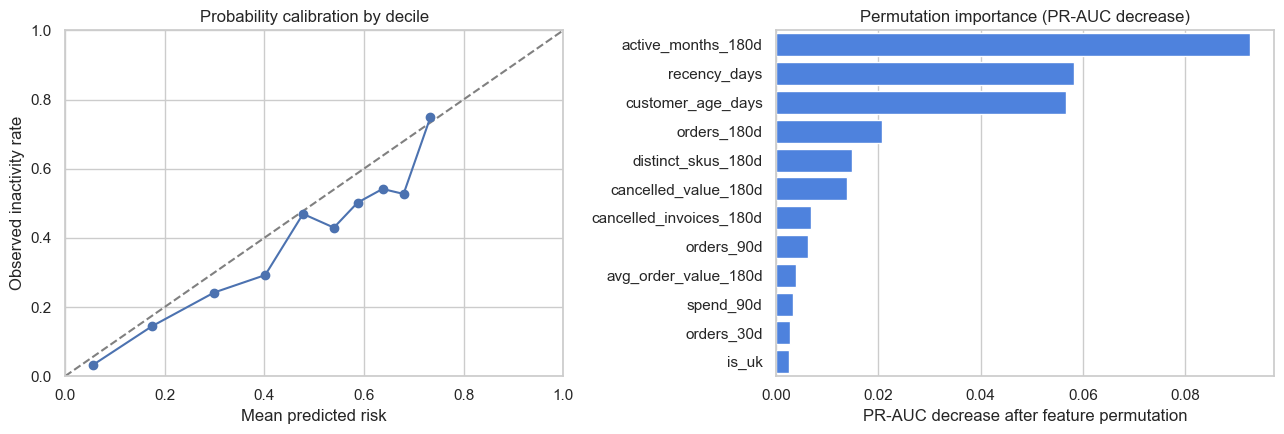

,calibration_bin,customers,mean_predicted_risk,actual_inactivity_rate
0,1,278,5.6%,3.2%
1,2,277,17.4%,14.4%
2,3,277,29.9%,24.2%
3,4,277,40.2%,29.2%
4,5,277,47.8%,46.9%
5,6,277,54.0%,43.0%
6,7,277,58.7%,50.2%
7,8,277,63.7%,54.2%
8,9,277,68.0%,52.7%
9,10,278,73.3%,74.8%


,feature,pr_auc_drop,std
15,active_months_180d,0.0927,0.0039
0,recency_days,0.0582,0.0040
1,customer_age_days,0.0566,0.0024
4,orders_180d,0.0208,0.0076
14,distinct_skus_180d,0.0148,0.0028
21,cancelled_value_180d,0.0139,0.0028
20,cancelled_invoices_180d,0.0068,0.0053
3,orders_90d,0.0063,0.0025
11,avg_order_value_180d,0.0039,0.0014
6,spend_90d,0.0034,0.0006


**Result interpretation:** The final-test Brier score is **0.203**. The calibration plot compares predicted probabilities with observed rates. The closer the points are to the diagonal, the more suitable the probabilities are for direct resource and budget estimation. The leading permutation-importance signals are **active_months_180d, recency_days, customer_age_days, orders_180d, distinct_skus_180d**。Importance indicates out-of-sample predictive value, not that changing a feature would causally prevent inactivity.

In [10]:
from sklearn.inspection import permutation_importance

scored["calibration_bin"] = pd.qcut(scored.risk_score.rank(method="first"), 10, labels=False) + 1
calibration = scored.groupby("calibration_bin").agg(
    customers=("customer_id", "size"),
    mean_predicted_risk=("risk_score", "mean"),
    actual_inactivity_rate=("inactive_90d", "mean")
).reset_index()

perm_sample = X_test.sample(min(2500, len(X_test)), random_state=42)
perm_y = y_test.loc[perm_sample.index]
perm = permutation_importance(
    final_model, perm_sample, perm_y, scoring="average_precision",
    n_repeats=4, random_state=42, n_jobs=1
)
importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "pr_auc_drop": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("pr_auc_drop", ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].plot(calibration.mean_predicted_risk, calibration.actual_inactivity_rate, marker="o")
axes[0].set(title="Probability calibration by decile", xlabel="Mean predicted risk", ylabel="Observed inactivity rate", xlim=(0, 1), ylim=(0, 1))
sns.barplot(data=importance, y="feature", x="pr_auc_drop", ax=axes[1], color="#367BF5")
axes[1].set(title="Permutation importance (PR-AUC decrease)", xlabel="PR-AUC decrease after feature permutation", ylabel="")
plt.tight_layout()
plt.show()
display(calibration.style.format({"customers": "{:,.0f}", "mean_predicted_risk": "{:.1%}", "actual_inactivity_rate": "{:.1%}"}))
display(importance.style.format({"pr_auc_drop": "{:.4f}", "std": "{:.4f}"}))

calibration.to_csv(OUTPUT_DIR / "final_test_calibration.csv", index=False)
importance.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)

top_features = ", ".join(importance.head(5).feature.tolist())
display(Markdown(
    f"**Result interpretation:** The final-test Brier score is **{final_metrics['Brier']:.3f}**. The calibration plot compares predicted probabilities with observed rates. "
    "The closer the points are to the diagonal, the more suitable the probabilities are for direct resource and budget estimation. "
    f"The leading permutation-importance signals are **{top_features}**。"
    "Importance indicates out-of-sample predictive value, not that changing a feature would causally prevent inactivity."
))


## 11. Business conclusions and next steps

### Decisions this project can support

1. Score customers monthly when they have purchased during the previous 180 days;
2. Under fixed contact capacity, send the highest-risk tier into a controlled CRM candidate list;
3. Monitor actual inactivity, calibration, model drift, and Top-K lift by risk decile;
4. Keep a randomized control group within the high-risk list to measure the incremental effect of email, coupons, or service outreach.

### What the project cannot prove

- No purchase for 90 days does not mean permanent churn;
- Predictive risk factors are not causal retention levers;
- The data contain no campaign cost, margin, or contact outcome, so retention ROI cannot be estimated;
- The data represent one UK retailer. Deployment on Tmall, JD, Pinduoduo, or Amazon requires new windows, labels, and thresholds.

### Production extensions

- Generate the same customer snapshot in SQL every month;
- Add training data only when labels have matured and preserve the 90-day purge gap;
- Track data, feature, model, and threshold versions;
- Monitor PR-AUC, Top-K lift, calibration, feature drift, and experiment incrementality.

This project directly demonstrates **classification models for behavioral data analysis with systematic cross-validation** and a **reproducible Python/SQL feature and evaluation pipeline**. The 48,079 rows are repeated customer-month snapshots—not 48,079 independent customers—and must not be used to inflate the resume's customer count.
